# **Historical and Architectural Landmarks Recognizer**

The goal of this project is to classify 13 different Historical and Architectural Landmarks.The landmarks are:
* Angkor Wat (Cambodia)
* The Forbidden City (China)
* Taj Mahal (India)
* Cologne Cathedral (Germany)
* Petra (Jordan)
* Dome of the Rock (Jerusalem)
* Hagia Sophia (Istanbul, Turkey)
* Alhambra (Spain)
* Palace of Versailles (France)
* Colosseum (Italy)
* Great Pyramid of Giza (Egypt)
* Machu Picchu (Peru)
* Chichen Itza (Mexico)

# **Importing Necessary Libraries**

In [ ]:
%matplotlib inline
bs = 16 # batch size

In [ ]:
!pip install -Uqq fastai fastbook nbdev ddgs==9.5.4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 719.8/719.8 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 21.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 15.6 MB/s eta 0:00:00


In [ ]:
from fastai import *
from fastbook import *
from fastai.vision.all import *
from fastai.vision.widgets import *
import os
from ddgs import DDGS
import time
from tqdm.notebook import tqdm
import torch
from google.colab import drive
from pathlib import Path
from shutil import copytree,rmtree
import shutil
import pandas as pd
import matplotlib.pyplot as plt
from tabulate import tabulate

In [ ]:
# Python version
!python --version

# PyTorch and torchvision
import torch, torchvision
print("PyTorch:", torch.__version__)
print("TorchVision:", torchvision.__version__)

# FastAI
import fastai
print("FastAI:", fastai.__version__)


Python 3.12.11
PyTorch: 2.8.0+cu126
TorchVision: 0.23.0+cu126
FastAI: 2.8.4


# **Mounting Drive and Setting Up Project Directory**

In [ ]:
drive.mount('/content/drive')

Mounted at /content/drive


**Defining the folder path**

In [ ]:
folder_path = '/content/drive/My Drive/Master_Course/Landmark Recognizer'

**Create the folder if it does not exists**

In [ ]:
os.makedirs(folder_path, exist_ok=True)

**Change to that directory**

In [ ]:
%cd '/content/drive/My Drive/Master_Course/Landmark Recognizer/'

/content/drive/My Drive/Master_Course/Landmark Recognizer


In [ ]:
#Check if the directory is correct
print(f"Current directory: {os.getcwd()}")

Current directory: /content/drive/My Drive/Master_Course/Landmark Recognizer


# **Fetch Data**

**Loading from Dataloaders**

In [ ]:
data_path = "./data"
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,                        # get_image_files returns a list of all images in that path recursively by default
    splitter=RandomSplitter(valid_pct=0.1, seed=42),  # getting 90-10 train-validation split
    get_y=parent_label,                               # taking the folder name as labels
    item_tfms=Resize(128))                            # resizing to get the image of same shape

In [ ]:
version=1
dataloader_path="./dataloaders"

**Saving a new version of the dataloader:**

In [ ]:
block = dblock.new(item_tfms=RandomResizedCrop(224, min_scale=0.5), batch_tfms=aug_transforms())
dls = dblock.dataloaders(data_path, bs = bs)
torch.save(dls, f"{dataloader_path}/landmark_dataloaders_v{version}.pkl")

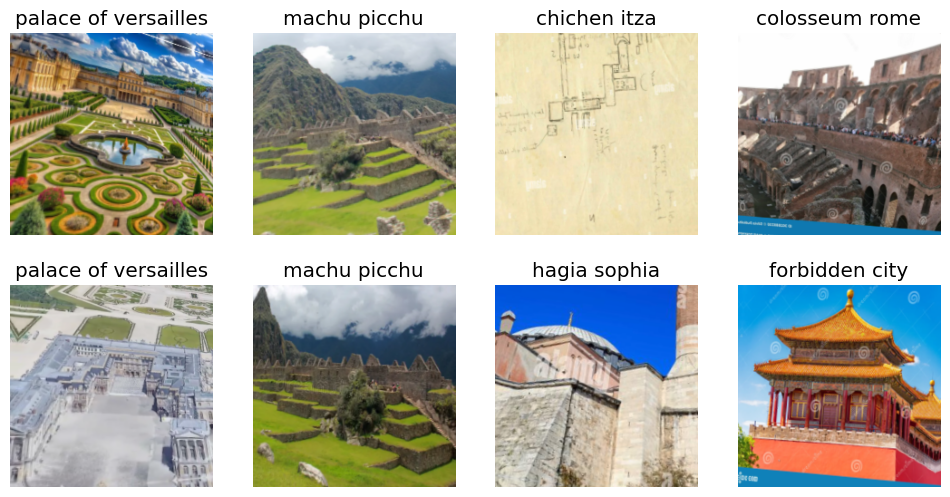

In [ ]:
dls.train.show_batch(max_n=8, nrows=2)

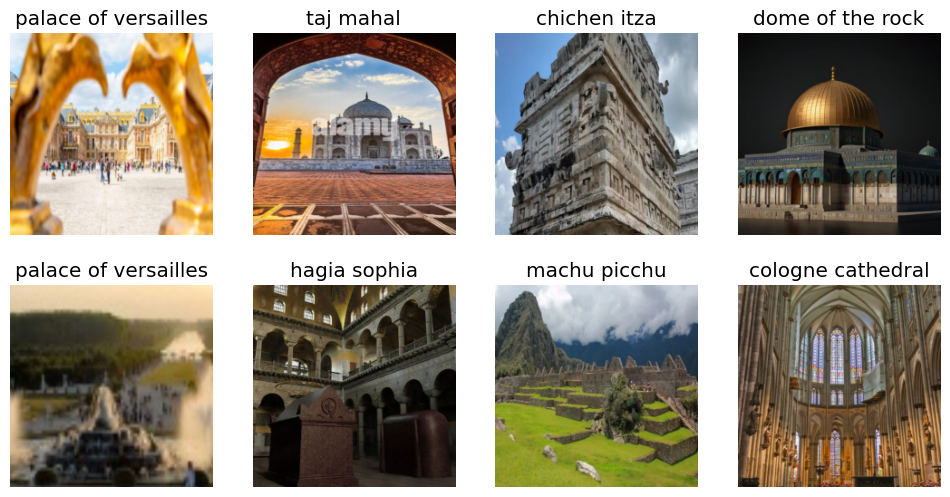

In [ ]:
dls.valid.show_batch(max_n=8, nrows=2)

# **Training and Data Cleaning**

In [ ]:
train_size = len(dls.train.dataset)
valid_size = len(dls.valid.dataset)

In [ ]:
model_path="./models"

**Download and load a pre-trained vision model**


*   ResNet 34 is used here


In [ ]:
model = vision_learner(dls, resnet34, metrics=[error_rate,accuracy])

Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 128MB/s]


**Fine tune the models for 3 epochs**

In [ ]:
model.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,1.086142,0.503952,0.157360,0.842640,07:24


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.448467,0.174120,0.050761,0.949239,01:53
1,0.228272,0.086537,0.027919,0.972081,01:50
2,0.113461,0.039498,0.017766,0.982234,01:50


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


**Saving the model state for version 0**

In [ ]:
model.save(f"landmark_recognizer_v0")

Path('models/landmark_recognizer_v0.pth')

In [ ]:
model.load(f"landmark_recognizer_v0")

**Confusion Matrix**

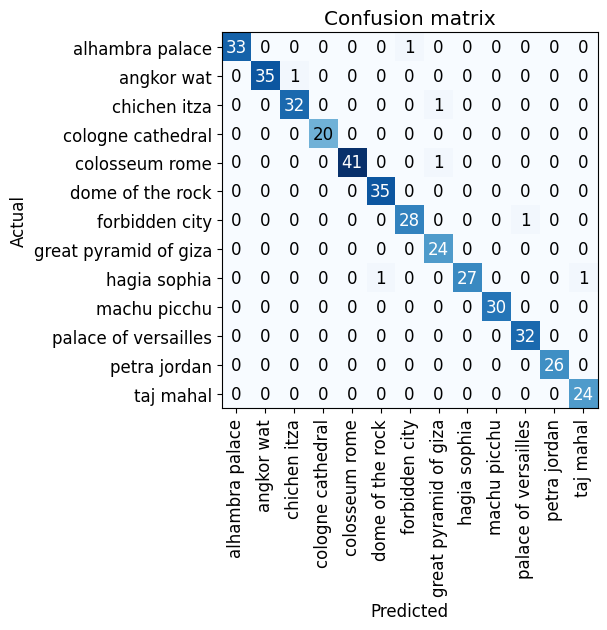

In [ ]:
interp = ClassificationInterpretation.from_learner(model)
interp.plot_confusion_matrix(figsize=(6, 8))

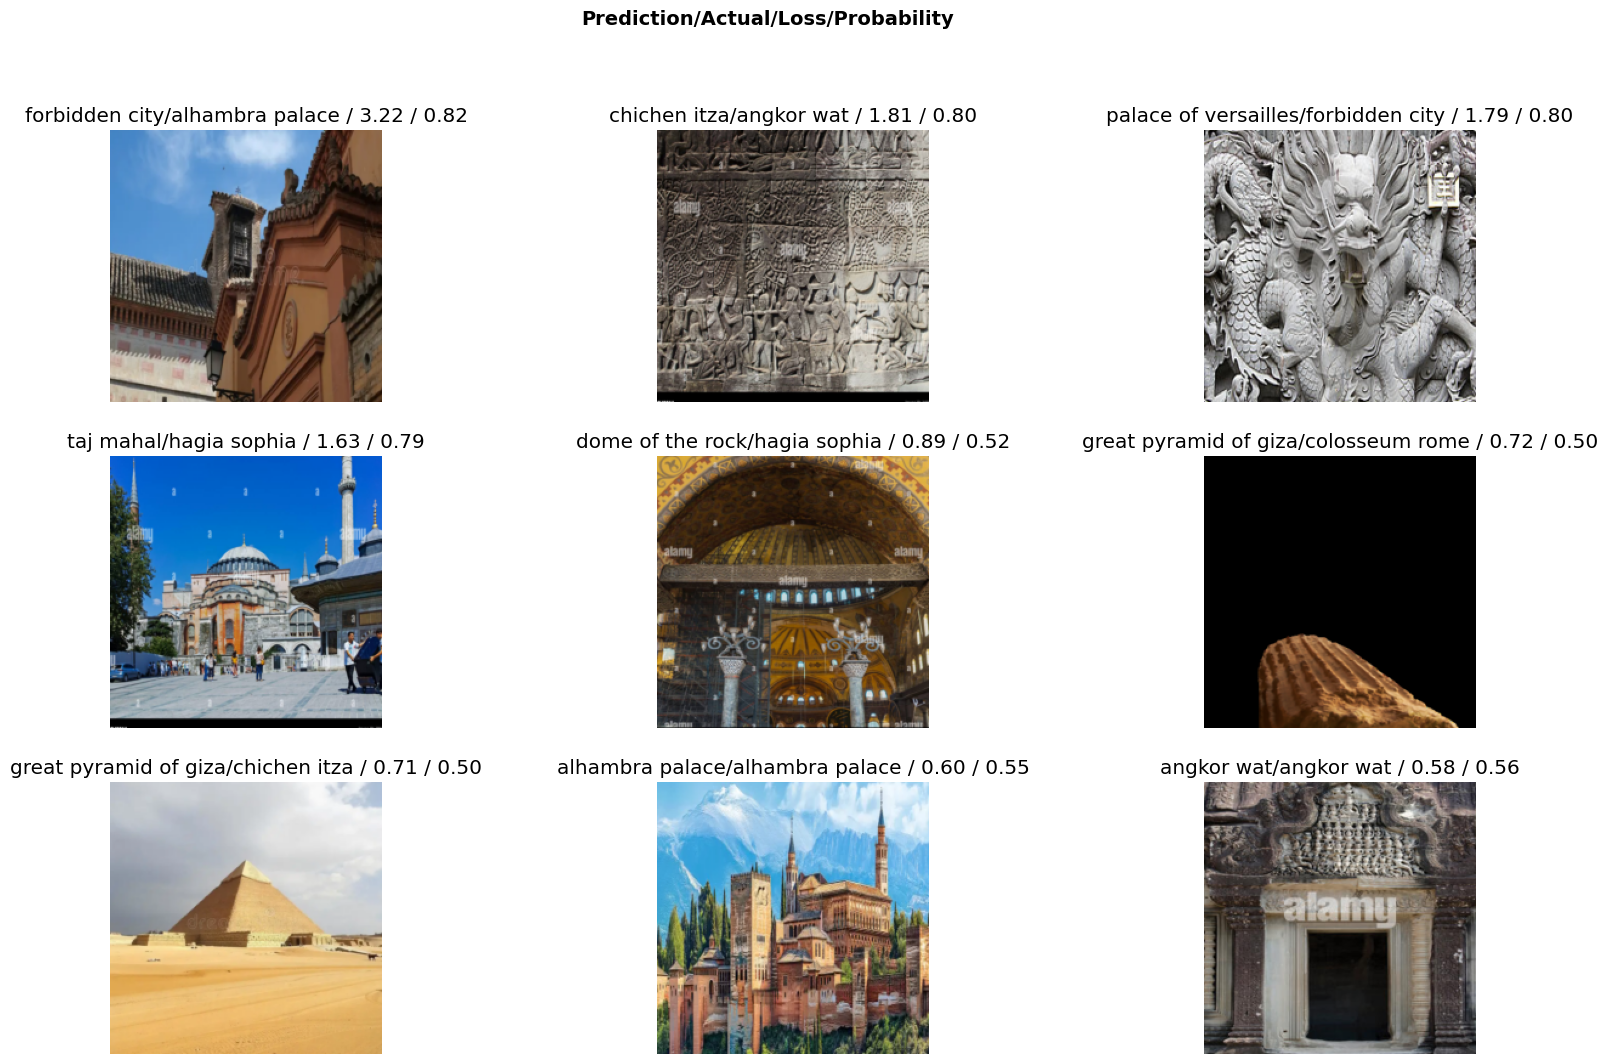

In [ ]:
interp.plot_top_losses(9, nrows=3,figsize=(20,12))

We have trained ResNet34 model on our raw dataset. Now, we'll clean the dataset and use this cleaned version to train further models.

**Clean Dataset**

In [ ]:
cleaner = ImageClassifierCleaner(model)
cleaner

In [ ]:
for idx in cleaner.delete(): cleaner.fns[idx].unlink()  # delete irrelevant data
for idx,cat in cleaner.change(): shutil.move(str(cleaner.fns[idx]), f"{data_path}/{cat}")

# **DataLoader**

In [ ]:
version=2
dataloader_path="./dataloaders"

In [ ]:
data_path = "./data"
dblock = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items=get_image_files,                        # get_image_files returns a list of all images in that path recursively by default
    splitter=RandomSplitter(valid_pct=0.1, seed=42),  # getting 90-10 train-validation split
    get_y=parent_label,                               # taking the folder name as labels
    item_tfms=Resize(128))                            # resizing to get the image of same shape

In [ ]:
block = dblock.new(item_tfms=RandomResizedCrop(224, min_scale=0.5), batch_tfms=aug_transforms())
dls = dblock.dataloaders(data_path, bs = bs)
torch.save(dls, f"{dataloader_path}/landmark_dataloaders_v{version}.pkl")

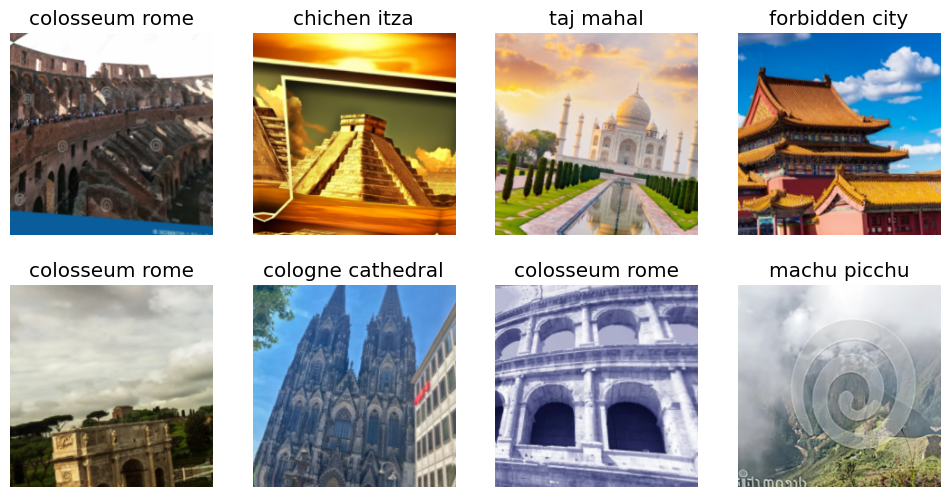

In [ ]:
dls.train.show_batch(max_n=8, nrows=2)

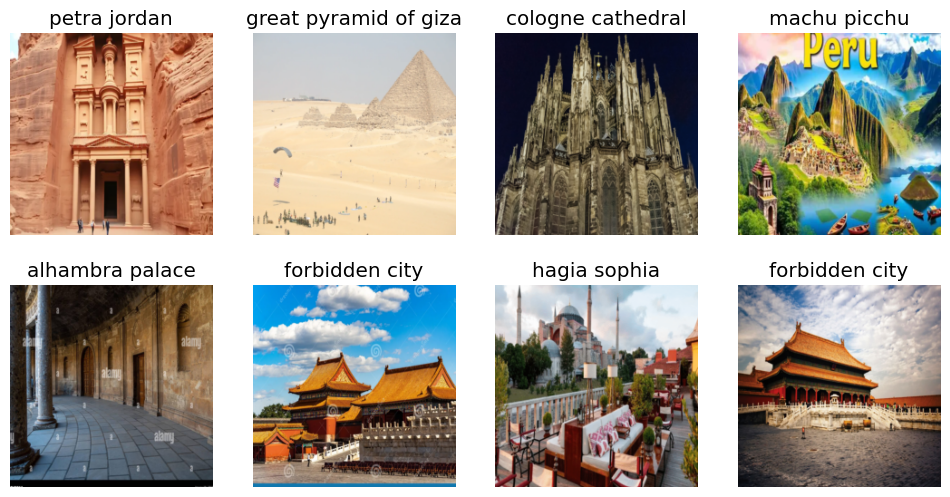

In [ ]:
dls.valid.show_batch(max_n=8, nrows=2)

# **Retrain ResNet34**

In [ ]:
results=[]

In [ ]:
model = vision_learner(dls, resnet34,metrics=[error_rate, accuracy])

**Fine tune the model**

In [ ]:
model.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,1.016801,0.442937,0.115702,0.884298,01:48


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.429723,0.261017,0.063361,0.936639,01:40
1,0.227659,0.123619,0.027548,0.972452,01:41
2,0.127758,0.094673,0.019284,0.980716,01:43


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
results.append(["ResNet-34", round(model.validate()[2], 2)])

In [ ]:
version=1
model.save(f"landmark_recognizer_resnet34_v{version}")

Path('models/landmark_recognizer_resnet34_v1.pth')

In [ ]:
version=1
model.load(f"landmark_recognizer_resnet34_v{version}")

**Confusion Matrix for ResNet34**

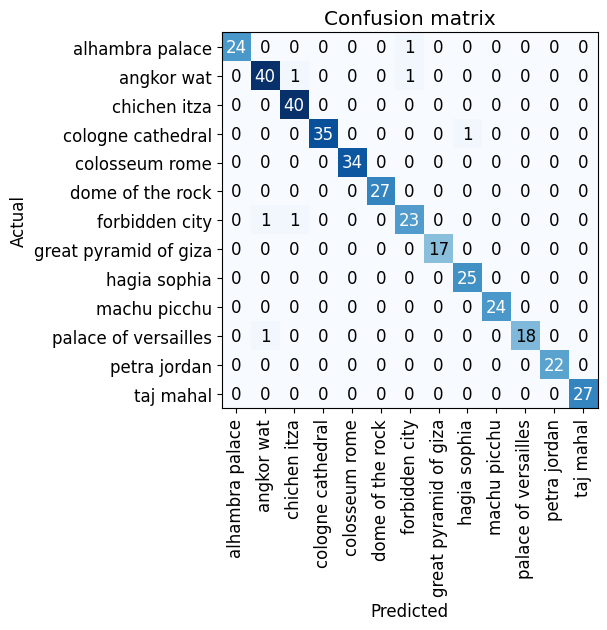

In [ ]:
interp = ClassificationInterpretation.from_learner(model)
interp.plot_confusion_matrix(figsize=(6, 8))

Images with the highest prediction loss

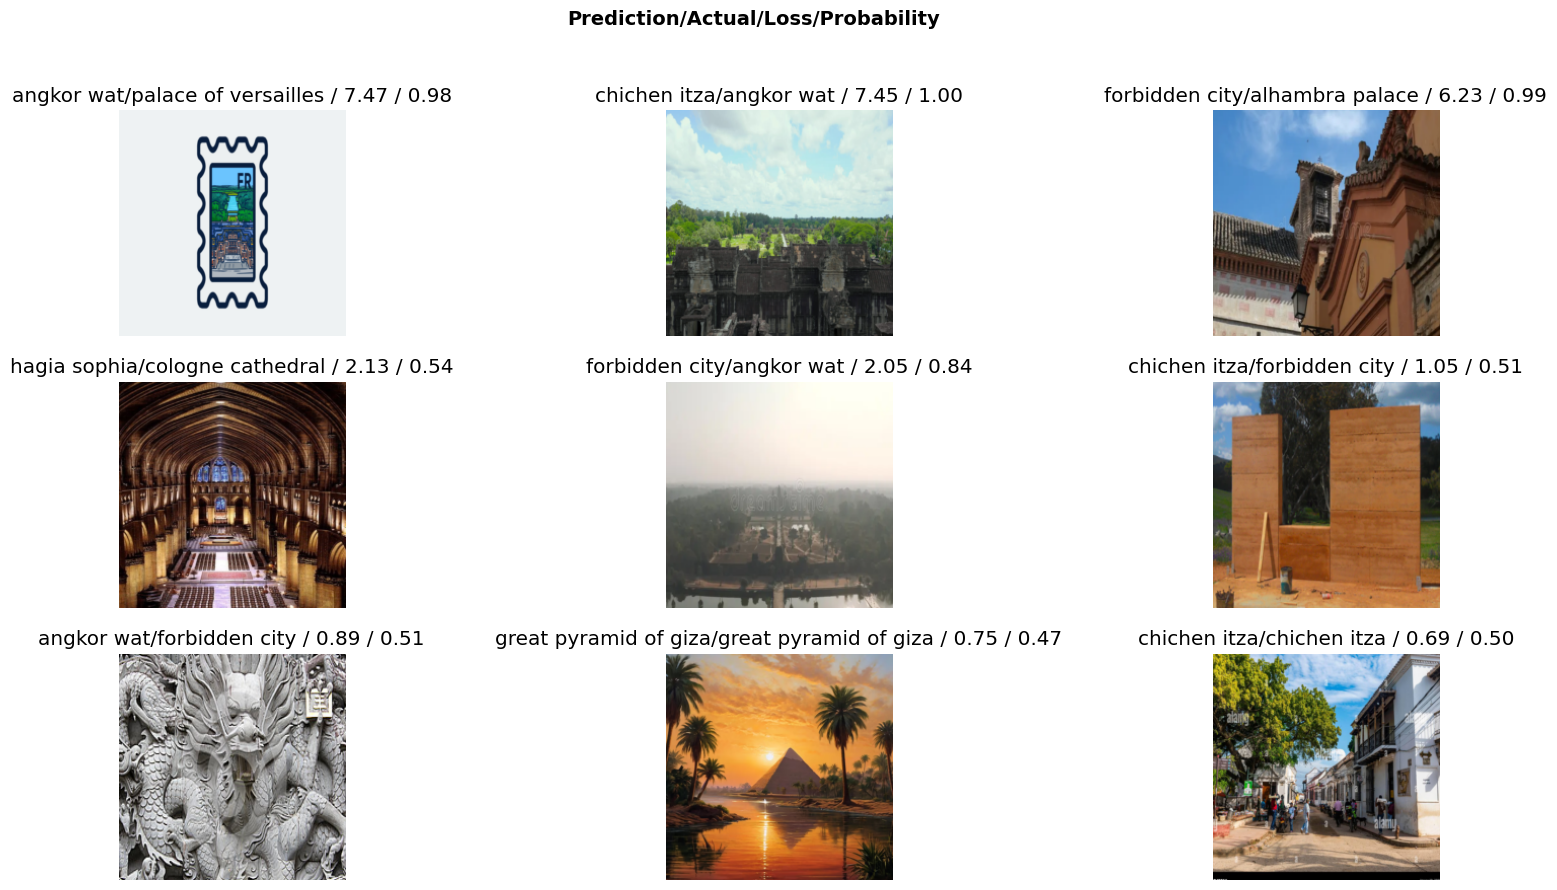

In [ ]:
interp.plot_top_losses(9, nrows=3,figsize=(20,10))

**Export the model for inference**

In [ ]:
version=1
model.export(f"./models/landmark_recognizer_model_v{version}.pkl")

# **MobileNet V3 (Small)**

In [ ]:
model = vision_learner(dls, mobilenet_v3_small,metrics=[error_rate, accuracy])

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=MobileNet_V3_Small_Weights.IMAGENET1K_V1`. You can also use `weights=MobileNet_V3_Small_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/mobilenet_v3_small-047dcff4.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v3_small-047dcff4.pth


100%|██████████| 9.83M/9.83M [00:00<00:00, 80.6MB/s]


**Fine tune the model**

In [ ]:
model.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,1.221341,0.564871,0.146006,0.853994,01:48


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.765957,0.380351,0.079890,0.920110,01:44
1,0.543382,0.289694,0.082645,0.917355,01:41
2,0.419562,0.259988,0.066116,0.933884,01:41


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
results.append(["MobileNetV3-Small", round(model.validate()[2], 2)])

Confusion Matrix for MobileNet V3-small

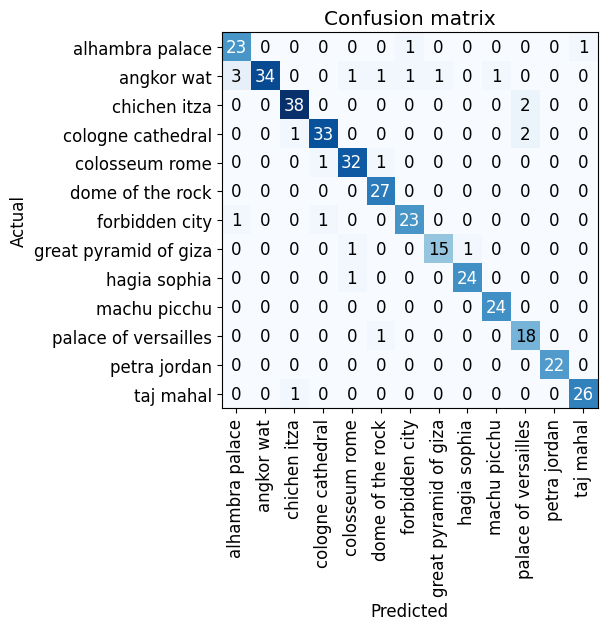

In [ ]:
interp = ClassificationInterpretation.from_learner(model)
interp.plot_confusion_matrix(figsize=(6, 8))

Images with the highest prediction loss

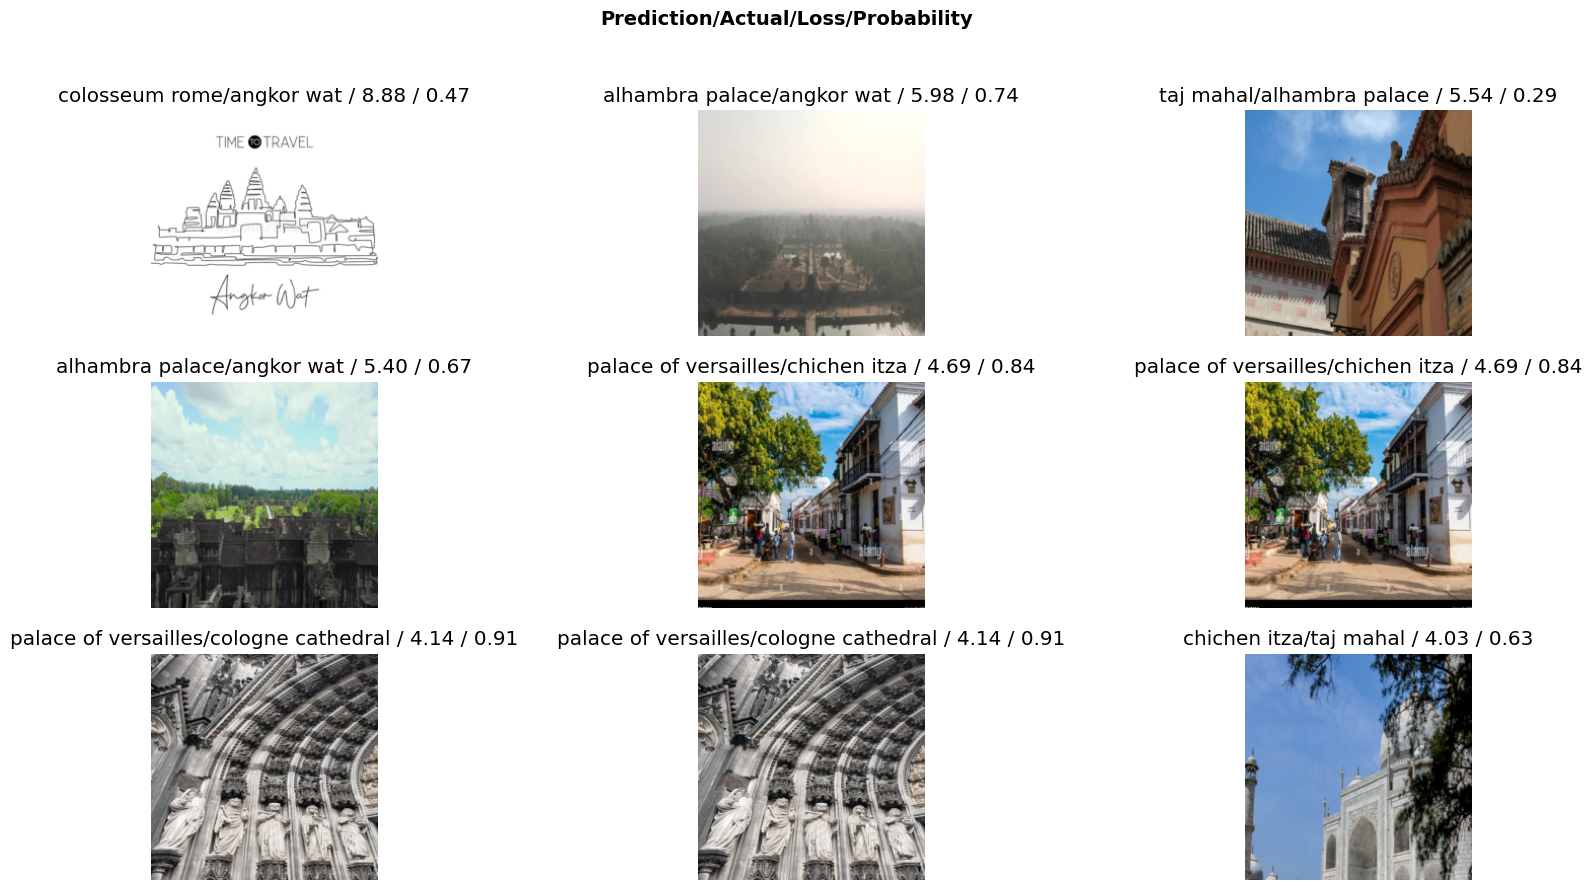

In [ ]:
interp.plot_top_losses(9, nrows=3,figsize=(20,10))

# **EfficientNet B0**

In [ ]:
model = vision_learner(dls, efficientnet_b0,metrics=[error_rate, accuracy])

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 127MB/s] 


**Fine tune the model**

In [ ]:
model.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,1.145785,0.617214,0.173554,0.826446,01:55


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.668495,0.409849,0.115702,0.884298,01:45
1,0.451791,0.275045,0.063361,0.936639,01:46
2,0.357278,0.244448,0.052342,0.947658,01:43


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
results.append(["EfficientNet-B0", round(model.validate()[2], 2)])

Confusion Matrix for EfficientNet B0

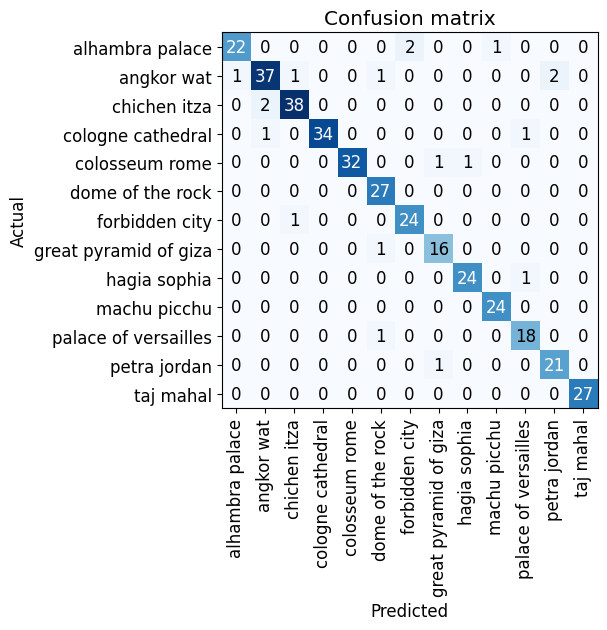

In [ ]:
interp = ClassificationInterpretation.from_learner(model)
interp.plot_confusion_matrix(figsize=(6, 8))

Images with the highest prediction loss

In [ ]:
interp.plot_top_losses(9, nrows=3,figsize=(20,10))

# **EfficientNet B1**

In [ ]:
model = vision_learner(dls, efficientnet_b1,metrics=[error_rate, accuracy])

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B1_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/efficientnet_b1_rwightman-bac287d4.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b1_rwightman-bac287d4.pth


100%|██████████| 30.1M/30.1M [00:00<00:00, 77.0MB/s]


In [ ]:
model.fine_tune(3)

epoch,train_loss,valid_loss,error_rate,accuracy,time
0,1.007784,0.572785,0.159780,0.840220,01:56


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch,train_loss,valid_loss,error_rate,accuracy,time
0,0.509229,0.398333,0.126722,0.873278,01:49
1,0.403458,0.337899,0.099174,0.900826,01:58
2,0.326776,0.256363,0.077135,0.922865,01:52


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [ ]:
results.append(["EfficientNet-B1", round(model.validate()[2], 2)])

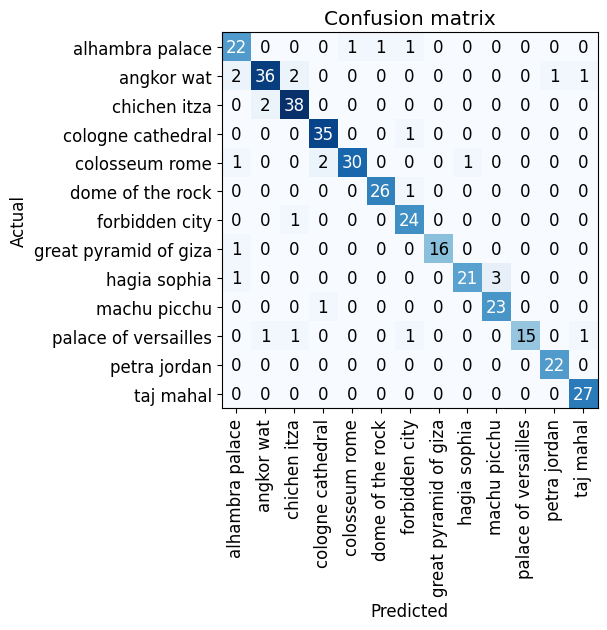

In [ ]:
interp = ClassificationInterpretation.from_learner(model)
interp.plot_confusion_matrix(figsize=(6, 8))

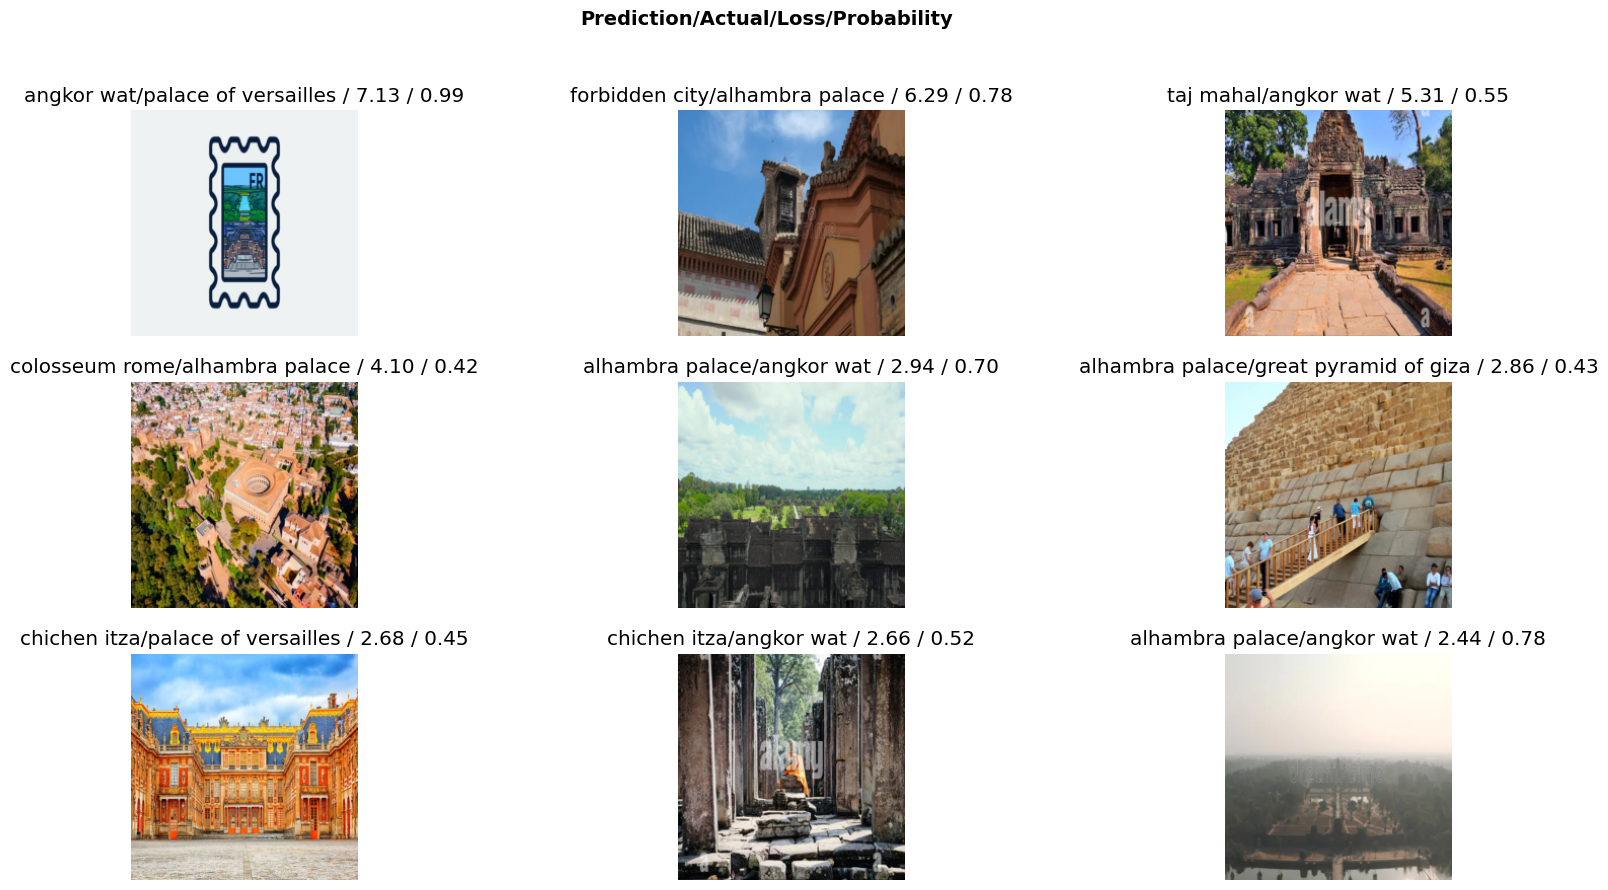

In [ ]:
interp.plot_top_losses(9, nrows=3,figsize=(20,10))

# **Model Comparison**

In [ ]:
print(tabulate(results, headers=["Model", "Accuracy"], tablefmt="fancy_grid"))

╒═══════════════════╤════════════╕
│ Model             │   Accuracy │
╞═══════════════════╪════════════╡
│ ResNet-34         │       0.98 │
├───────────────────┼────────────┤
│ MobileNetV3-Small │       0.93 │
├───────────────────┼────────────┤
│ EfficientNet-B0   │       0.95 │
├───────────────────┼────────────┤
│ EfficientNet-B1   │       0.92 │
╘═══════════════════╧════════════╛
